# Cliff Walking with SARSA
This notebook implements SARSA (on-policy TD control) on the Cliff Walking environment using an ε-greedy exploration strategy.

## Objectives
- Train an agent with SARSA.
- Plot cumulative reward per episode.
- Visualize the learned policy.

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

## Environment Setup
We use Gymnasium's `CliffWalking-v0` environment.
The environment is a 4×12 grid:
- Start: bottom-left corner
- Goal: bottom-right corner
- Cliff: cells between start and goal on the bottom row
- Falling into the cliff gives a large negative reward and resets the agent.

In [15]:
env = gym.make('CliffWalking-v1')
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f'Number of states: {n_states}')
print(f'Number of actions: {n_actions}')

Number of states: 48
Number of actions: 4


## SARSA Parameters

In [7]:
# Learning parameters
alpha = 0.5      # Learning rate
gamma = 0.99     # Discount factor
epsilon = 0.1    # Exploration probability
episodes = 500   # Number of training episodes

# Q-table initialized to zero
Q = defaultdict(lambda: np.zeros(n_actions))

## ε-Greedy Policy

In [8]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state]))

## SARSA Training Loop
The SARSA update rule is:
$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma Q(s',a') - Q(s,a)]$$

In [9]:
episode_rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    action = epsilon_greedy(Q, state, epsilon)

    done = False
    total_reward = 0

    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_action = epsilon_greedy(Q, next_state, epsilon)

        # SARSA update
        td_target = reward + gamma * Q[next_state][next_action]
        td_error = td_target - Q[state][action]
        Q[state][action] += alpha * td_error

        state = next_state
        action = next_action
        total_reward += reward

        done = terminated or truncated

    episode_rewards.append(total_reward)

print('Training completed.')

Training completed.


## Learning Curve

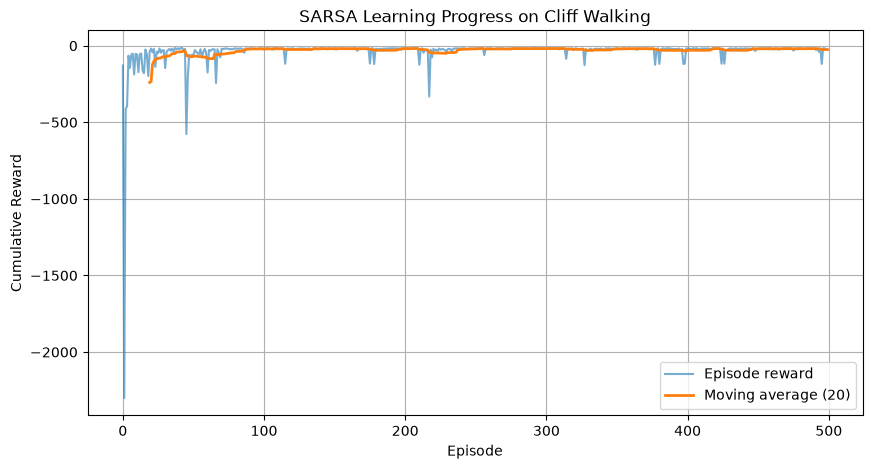

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.6, label='Episode reward')

# Moving average for smoother visualization
window = 20
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, episodes), moving_avg, linewidth=2, label='Moving average (20)')

plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.title('SARSA Learning Progress on Cliff Walking')
plt.legend()
plt.grid(True)
plt.show()

## Extract Learned Policy

In [11]:
def extract_policy(Q):
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        policy[s] = int(np.argmax(Q[s]))
    return policy

policy = extract_policy(Q)
policy_grid = policy.reshape(4, 12)

policy_grid

array([[1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 1, 2],
       [1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 2],
       [0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 0, 2],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

## Visualize Learned Policy
Action mapping:
- 0: Up (↑)
- 1: Right (→)
- 2: Down (↓)
- 3: Left (←)

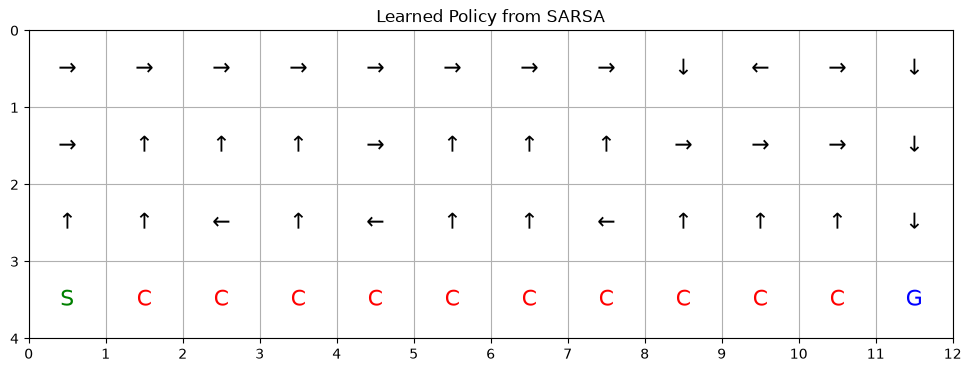

In [12]:
arrow_map = {
    0: '↑',
    1: '→',
    2: '↓',
    3: '←'
}

policy_arrows = np.vectorize(arrow_map.get)(policy_grid)

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.set_xticks(range(13))
ax.set_yticks(range(5))
ax.grid(True)
ax.invert_yaxis()

# Draw arrows
for r in range(4):
    for c in range(12):
        state = r * 12 + c

        # Mark start, goal, and cliff cells
        if state == 36:
            text = 'S'
            color = 'green'
        elif state == 47:
            text = 'G'
            color = 'blue'
        elif 37 <= state <= 46:
            text = 'C'
            color = 'red'
        else:
            text = policy_arrows[r, c]
            color = 'black'

        ax.text(c + 0.5, r + 0.5, text,
                ha='center', va='center', fontsize=16, color=color)

ax.set_title('Learned Policy from SARSA')
ax.set_aspect('equal')
plt.show()

## Inspect Q-values for Selected States

In [13]:
for state in [36, 24, 12, 0]:
    print(f'State {state}: {Q[state]}')

State 36: [ -18.81798171 -118.13025125  -20.68418017  -20.20862356]
State 24: [-17.96545337 -23.89683443 -20.67930286 -19.8110278 ]
State 12: [-19.41169904 -16.76377904 -20.11662608 -19.25068623]
State 0: [-19.07543663 -15.93068573 -19.54361816 -19.20212551]


## Discussion
- SARSA is an **on-policy** method because it learns the value of the policy it actually follows.
- The ε-greedy policy encourages exploration.
- In Cliff Walking, SARSA typically learns a safer path that avoids the cliff because exploratory actions near the cliff can be costly.
- This often differs from off-policy methods such as Q-learning, which may learn a riskier path closer to the cliff.